In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [31]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz, hstack
from sklearn.preprocessing import StandardScaler, LabelEncoder
import sklearn.utils as sku

# --------------------------------------------------------
# PATHS
# --------------------------------------------------------

DATA_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_FILE = "Data_files/labels_nltk.txt"
SORT_FILE = "txt_files/speeches_nltk_sort_idx.txt"

# --------------------------------------------------------
# LOAD DATA
# --------------------------------------------------------

labels_nltk = np.genfromtxt(
    LABEL_FILE,
    delimiter=";",
    dtype=str,
    skip_header=1
)

data_nltk = load_npz(DATA_FILE)

sort_idx = np.genfromtxt(
    SORT_FILE,
    delimiter="\n",
    dtype=int
)

print("Initial data shape:", data_nltk.shape)
print("Initial number of labels:", labels_nltk.shape[0])

assert data_nltk.shape[0] == labels_nltk.shape[0]

# --------------------------------------------------------
# REMOVE SPEECHES, KEEP ONLY ARTICLES
# --------------------------------------------------------
# labels_nltk[:, 2] is assumed to mark speech/article.
# After inversion: speeches = 1, articles = 0.

labels_speeches = labels_nltk[:, 2].astype(int)
labels_speeches = np.abs(labels_speeches - 1)

article_mask = labels_speeches == 0

print("Number of articles:", article_mask.sum())
print("Number of speeches removed:", (~article_mask).sum())

data_nltk = data_nltk[article_mask]
labels_nltk = labels_nltk[article_mask]

assert data_nltk.shape[0] == labels_nltk.shape[0]

# --------------------------------------------------------
# KEEP TOP FEATURES
# --------------------------------------------------------

data_nltk = data_nltk[:, sort_idx][:, :2000]

print("Shape after sorting:", data_nltk.shape)

# --------------------------------------------------------
# ADD LIX SCORE
# --------------------------------------------------------

lix_scores = labels_nltk[:, 0].astype(np.float32)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_nltk = hstack(
    [lix_column, data_nltk],
    format="csr"
)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_nltk = scaler.fit_transform(data_nltk)

# --------------------------------------------------------
# KEEP ONLY TOP 10 MOST FREQUENT TOPICS
# --------------------------------------------------------

top_x = 10

topic_labels = labels_nltk[:, 1]

unique_topics, topic_counts = np.unique(
    topic_labels,
    return_counts=True
)

sorted_idx = np.argsort(topic_counts)[::-1]

top_topics = unique_topics[
    sorted_idx[:top_x]
]

topic_mask = np.isin(
    topic_labels,
    top_topics
)

print("\nOriginal number of articles:", data_nltk.shape[0])
print("Articles kept:", topic_mask.sum())
print("Articles removed:", (~topic_mask).sum())

print("\nTop topics kept:")
for topic in top_topics:
    count = np.sum(topic_labels == topic)
    print(f"{topic}: {count}")

# Apply topic filtering

data_nltk = data_nltk[topic_mask]
labels_nltk = labels_nltk[topic_mask]

assert data_nltk.shape[0] == labels_nltk.shape[0]

# --------------------------------------------------------
# ENCODE TOP-10 TOPICS
# --------------------------------------------------------

topic_labels = labels_nltk[:, 1]

label_encoder = LabelEncoder()

topic_labels_encoded = label_encoder.fit_transform(
    topic_labels
)

print("\nNumber of topics kept:",
      len(label_encoder.classes_))

print("\nEncoded classes:")
for i, topic in enumerate(label_encoder.classes_):
    print(f"{i}: {topic}")

# --------------------------------------------------------
# SHUFFLE ARTICLES AND TOPIC LABELS
# --------------------------------------------------------

data_comb, labels_comb = sku.shuffle(
    data_nltk,
    topic_labels_encoded,
    random_state=5466542
)

# --------------------------------------------------------
# TRAIN / VAL / TEST SPLIT
# --------------------------------------------------------

data_train, data_train_labels, \
data_val, data_val_labels, \
data_test, data_test_labels = bf.train_val_test_split(
    data_comb,
    labels_comb,
    val_size=0.20,
    test_size=0.10
)

# --------------------------------------------------------
# OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_comb.shape)
print("Final number of labels:", labels_comb.shape[0])

print("\nTrain shape:", data_train.shape)
print("Validation shape:", data_val.shape)
print("Test shape:", data_test.shape)

print("\nExample feature row:")
print(data_comb[0])

print("\nExample encoded topic label:")
print(labels_comb[0])

print("\nDecoded example topic:")
print(label_encoder.inverse_transform([labels_comb[0]])[0])

Initial data shape: (780044, 64478)
Initial number of labels: 780044
Number of articles: 775291
Number of speeches removed: 4753
Shape after sorting: (775291, 2000)

Original number of articles: 775291
Articles kept: 434564
Articles removed: 340727

Top topics kept:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796

Number of topics kept: 10

Encoded classes:
0: Cykling
1: Danmark
2: Film og tv
3: Fodbold
4: Forbrug
5: Internationalt
6: Kultur
7: Politik
8: Sport
9: Økonomi

Final data shape: (434564, 2001)
Final number of labels: 434564

Train shape: (304196, 2001)
Validation shape: (86912, 2001)
Test shape: (43456, 2001)

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17 stored elements and shape (1, 2001)>
  Coords	Values
  (0, 0)	4.7797837420240725
  (0, 14)	5.319611519912259
  (0, 2)	4.459600017587758
  (0, 636)	7.130992121384763
  (0, 13

# Functions

In [32]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [33]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [34]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [35]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    Layer1 = trial.suggest_int("Layer1", 64, 256)
    Layer2 = trial.suggest_int("Layer2", 32, 128)
    Layer3 = trial.suggest_int("Layer3", 8, 64)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    n_epochs = 10

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):
            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptModel().to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    best_validation_loss = float("inf")

    for epoch in range(n_epochs):

        print(f"Trial {trial.number} | Optuna epoch {epoch + 1}/{n_epochs}")

        training_loss, validation_loss = Train(
            model_opt,
            optimizer,
            loss_function,
            train_loader,
            validation_loader,
            device,
            1)

        current_validation_loss = validation_loss[-1]

        best_validation_loss = min(
            best_validation_loss,
            current_validation_loss
        )

        trial.report(current_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

# HP optimization

In [36]:
pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

study.optimize(
    objective,
    n_trials=30
)

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

[I 2026-06-06 00:32:33,430] A new study created in memory with name: no-name-a44ad31e-4f8f-4e16-81da-7ddc7475f239


Trial 0 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.22  | validation loss: 1.109
Trial 0 | Optuna epoch 2/10
EPOCH: 1 | training loss: 1.128  | validation loss: 1.092
Trial 0 | Optuna epoch 3/10
EPOCH: 1 | training loss: 1.101  | validation loss: 1.082
Trial 0 | Optuna epoch 4/10
EPOCH: 1 | training loss: 1.086  | validation loss: 1.08
Trial 0 | Optuna epoch 5/10
EPOCH: 1 | training loss: 1.073  | validation loss: 1.077
Trial 0 | Optuna epoch 6/10
EPOCH: 1 | training loss: 1.065  | validation loss: 1.078
Trial 0 | Optuna epoch 7/10
EPOCH: 1 | training loss: 1.057  | validation loss: 1.076
Trial 0 | Optuna epoch 8/10
EPOCH: 1 | training loss: 1.052  | validation loss: 1.084
Trial 0 | Optuna epoch 9/10
EPOCH: 1 | training loss: 1.046  | validation loss: 1.076
Trial 0 | Optuna epoch 10/10


[I 2026-06-06 00:37:32,606] Trial 0 finished with value: 1.0759125594186854 and parameters: {'learning_rate': 0.001130737814178179, 'batch_size': 64, 'Layer1': 104, 'Layer2': 72, 'Layer3': 57, 'dropout_rate': 0.22022698836777543}. Best is trial 0 with value: 1.0759125594186854.


EPOCH: 1 | training loss: 1.043  | validation loss: 1.077
Trial 1 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.66  | validation loss: 1.248
Trial 1 | Optuna epoch 2/10
EPOCH: 1 | training loss: 1.302  | validation loss: 1.154
Trial 1 | Optuna epoch 3/10
EPOCH: 1 | training loss: 1.236  | validation loss: 1.127
Trial 1 | Optuna epoch 4/10
EPOCH: 1 | training loss: 1.201  | validation loss: 1.11
Trial 1 | Optuna epoch 5/10
EPOCH: 1 | training loss: 1.175  | validation loss: 1.099
Trial 1 | Optuna epoch 6/10
EPOCH: 1 | training loss: 1.157  | validation loss: 1.091
Trial 1 | Optuna epoch 7/10
EPOCH: 1 | training loss: 1.138  | validation loss: 1.084
Trial 1 | Optuna epoch 8/10
EPOCH: 1 | training loss: 1.124  | validation loss: 1.081
Trial 1 | Optuna epoch 9/10
EPOCH: 1 | training loss: 1.106  | validation loss: 1.077
Trial 1 | Optuna epoch 10/10


[I 2026-06-06 00:43:25,029] Trial 1 finished with value: 1.073890735281409 and parameters: {'learning_rate': 7.180297246129629e-05, 'batch_size': 128, 'Layer1': 167, 'Layer2': 110, 'Layer3': 13, 'dropout_rate': 0.2314143524111005}. Best is trial 1 with value: 1.073890735281409.


...

EPOCH: 1 | training loss: 0.853  | validation loss: 1.08
Trial 28 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.257  | validation loss: 1.092
Trial 28 | Optuna epoch 2/10
EPOCH: 1 | training loss: 1.097  | validation loss: 1.068
Trial 28 | Optuna epoch 3/10
EPOCH: 1 | training loss: 1.054  | validation loss: 1.057
Trial 28 | Optuna epoch 4/10
EPOCH: 1 | training loss: 1.019  | validation loss: 1.048
Trial 28 | Optuna epoch 5/10
EPOCH: 1 | training loss: 0.988  | validation loss: 1.045
Trial 28 | Optuna epoch 6/10
EPOCH: 1 | training loss: 0.958  | validation loss: 1.044
Trial 28 | Optuna epoch 7/10
EPOCH: 1 | training loss: 0.932  | validation loss: 1.048
Trial 28 | Optuna epoch 8/10
EPOCH: 1 | training loss: 0.906  | validation loss: 1.053
Trial 28 | Optuna epoch 9/10
EPOCH: 1 | training loss: 0.882  | validation loss: 1.064
Trial 28 | Optuna epoch 10/10


[I 2026-06-06 02:30:33,011] Trial 28 finished with value: 1.04350702389965 and parameters: {'learning_rate': 8.958005799599122e-05, 'batch_size': 32, 'Layer1': 178, 'Layer2': 117, 'Layer3': 60, 'dropout_rate': 0.1846872095527321}. Best is trial 15 with value: 1.0422042136866496.


EPOCH: 1 | training loss: 0.861  | validation loss: 1.071
Trial 29 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.511  | validation loss: 1.21
Trial 29 | Optuna epoch 2/10


[I 2026-06-06 02:31:48,466] Trial 29 pruned. 


EPOCH: 1 | training loss: 1.219  | validation loss: 1.131
Best trial:
FrozenTrial(number=15, state=<TrialState.COMPLETE: 1>, values=[1.0422042136866496], datetime_start=datetime.datetime(2026, 6, 6, 1, 29, 49, 939730), datetime_complete=datetime.datetime(2026, 6, 6, 1, 39, 16, 880326), params={'learning_rate': 0.00017893288225689048, 'batch_size': 32, 'Layer1': 133, 'Layer2': 113, 'Layer3': 50, 'dropout_rate': 0.11134831294302086}, user_attrs={}, system_attrs={}, intermediate_values={0: 1.0800219909651465, 1: 1.057326329254788, 2: 1.04540518945596, 3: 1.0422042136866496, 4: 1.0464832016180472, 5: 1.0540585839278744, 6: 1.063935959034096, 7: 1.0846162780417083, 8: 1.0932824638657086, 9: 1.1049344004166144}, distributions={'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128)), 'Layer1': IntDistribution(high=256, log=False, low=64, step=1), 'Layer2': IntDistribution(high=128, log=False, low=32, step=1), 

In [37]:
print(study.best_trial.params)

{'learning_rate': 0.00017893288225689048, 'batch_size': 32, 'Layer1': 133, 'Layer2': 113, 'Layer3': 50, 'dropout_rate': 0.11134831294302086}


# Split data for actual training

In [38]:
# --------------------------------------------------------
# split data into train, val, test sets
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_comb,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0.1
)

train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)
test_data = MyDataset(data_test, data_test_labels)

# Train the data with HP optimized parameters

In [39]:
best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = best_params["dropout_rate"]

n_epochs = 3

input_dim = data_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Starting setup...")
print("Best hyperparameters:", best_params)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

class TopicModel(nn.Module):

    def __init__(self):
        super(TopicModel, self).__init__()

        self.input_layer = nn.Linear(input_dim, Layer1)
        self.hidden_layer1 = nn.Linear(Layer1, Layer2)
        self.hidden_layer2 = nn.Linear(Layer2, Layer3)
        self.output_layer = nn.Linear(Layer3, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, inputs):

        x = self.input_layer(inputs)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output_layer(x)

        return x

print("Selecting device...")
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

print("Creating model...")
model = TopicModel().to(device)
print("Model created.")

print("Creating optimizer...")
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
print("Optimizer created.")

print("Creating loss function...")
loss_function = CrossEntropyLoss()
print("Loss function created.")

print("Creating data loaders...")
train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=sparse_collate
)

validation_loader = DataLoader(
    dataset=val_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

print("Data loaders created.")
print("Starting training...")

training_loss, validation_loss = Train(
    model,
    optimizer,
    loss_function,
    train_loader,
    validation_loader,
    device,
    n_epochs
)

print("Training finished.")
print("Training losses:")
print(training_loss)

print("Validation losses:")
print(validation_loss)

Starting setup...
Best hyperparameters: {'learning_rate': 0.00017893288225689048, 'batch_size': 32, 'Layer1': 133, 'Layer2': 113, 'Layer3': 50, 'dropout_rate': 0.11134831294302086}
Input dimension: 2001
Number of classes: 10
Selecting device...
Using device: cpu
Creating model...
Model created.
Creating optimizer...
Optimizer created.
Creating loss function...
Loss function created.
Creating data loaders...
Data loaders created.
Starting training...
EPOCH: 1 | training loss: 1.951  | validation loss: 1.874
EPOCH: 2 | training loss: 1.932  | validation loss: 1.877
EPOCH: 3 | training loss: 1.913  | validation loss: 1.891
Training finished.
Training losses:
[1.9510916690664912, 1.9324633759806256, 1.9128172760119106]
Validation losses:
[1.8738946378318833, 1.8770045810139055, 1.8911236031680465]


# Plotting the results

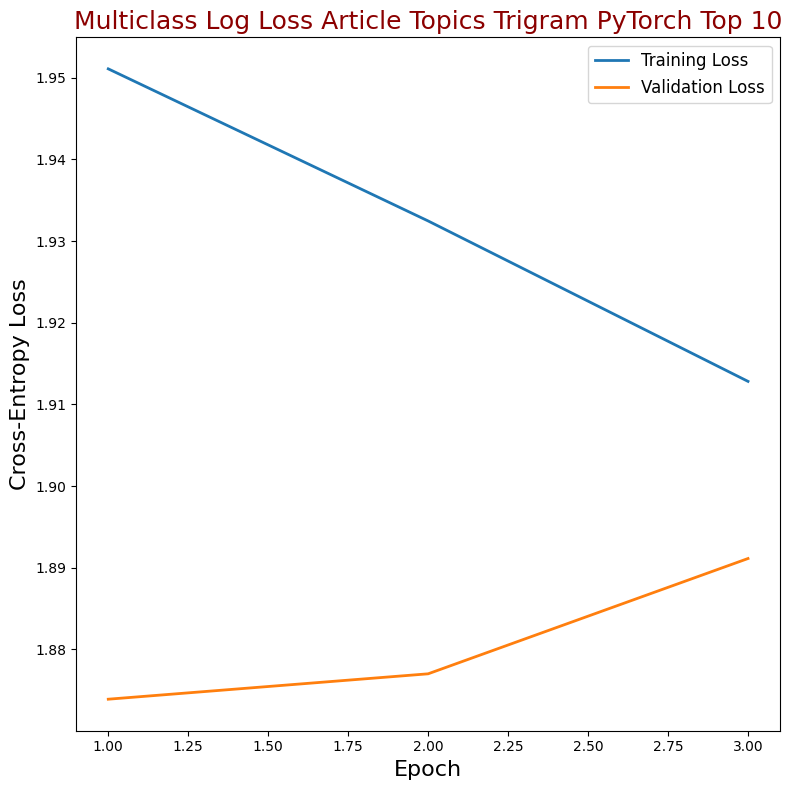


FINAL TEST RESULTS
Cross-Entropy Loss : 1.9160
Log Loss           : 1.9160
Accuracy           : 0.2961
Macro F1           : 0.0738
Weighted F1        : 0.2203


In [ ]:
# --------------------------------------------------------
# PLOT TRAINING / VALIDATION LOG LOSS
# AND EVALUATE FINAL TEST PERFORMANCE
# --------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss
)

# --------------------------------------------------------
# LOSS CURVE
# --------------------------------------------------------

epochs = np.arange(
    1,
    len(training_loss) + 1
)

plt.figure(figsize=(8, 8))

plt.plot(
    epochs,
    training_loss,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Cross-Entropy Loss",
    fontsize=16
)

plt.title(
    "Multiclass Log Loss Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Multiclass_LogLoss_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# TEST / VALIDATION SET EVALUATION
# --------------------------------------------------------

test_loader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

test_loss = 0.0
n_batches = 0

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device)

        outputs = model(input_batch)

        loss = loss_function(
            outputs,
            truth_batch.long()
        )

        test_loss += loss.item()
        n_batches += 1

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

# --------------------------------------------------------
# FINAL METRICS
# --------------------------------------------------------

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

final_test_loss = test_loss / n_batches

final_log_loss = log_loss(
    all_truths,
    all_probabilities,
    labels=np.arange(10)
)

test_accuracy = accuracy_score(
    all_truths,
    all_predictions
)

macro_f1 = f1_score(
    all_truths,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_truths,
    all_predictions,
    average="weighted"
)

# --------------------------------------------------------
# REPORT RESULTS
# --------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(
    f"Cross-Entropy Loss : {final_test_loss:.4f}"
)

print(
    f"Log Loss           : {final_log_loss:.4f}"
)

print(
    f"Accuracy           : {test_accuracy:.4f}"
)

print(
    f"Macro F1           : {macro_f1:.4f}"
)

print(
    f"Weighted F1        : {weighted_f1:.4f}"
)

print("=" * 50)

Generating predictions...


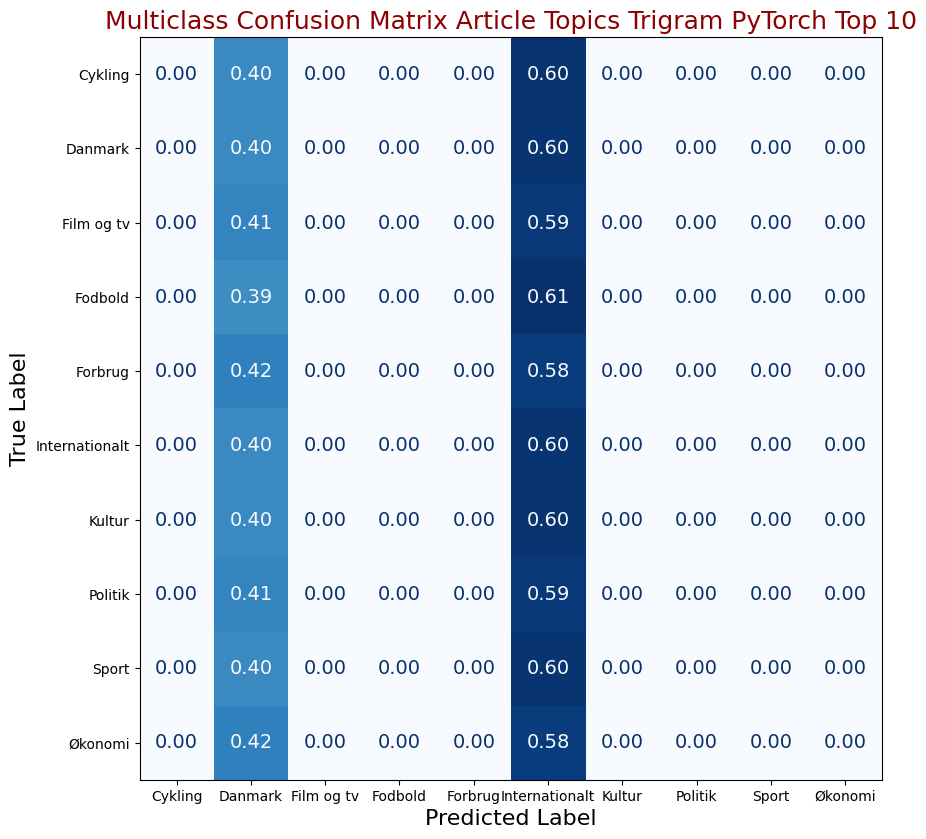

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PREDICTIONS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating predictions...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        predictions = pt.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

# --------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------------

cm = confusion_matrix(
    all_truths,
    all_predictions,
    normalize="true"
)

# Force 2 decimals
cm = np.round(cm, 2)

classes = label_encoder.classes_

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,
    values_format=".2f"   # FORCE 2 DECIMALS
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "Predicted Label",
    fontsize=16
)

plt.ylabel(
    "True Label",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ConfusionMatrix_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Generating prediction probabilities...


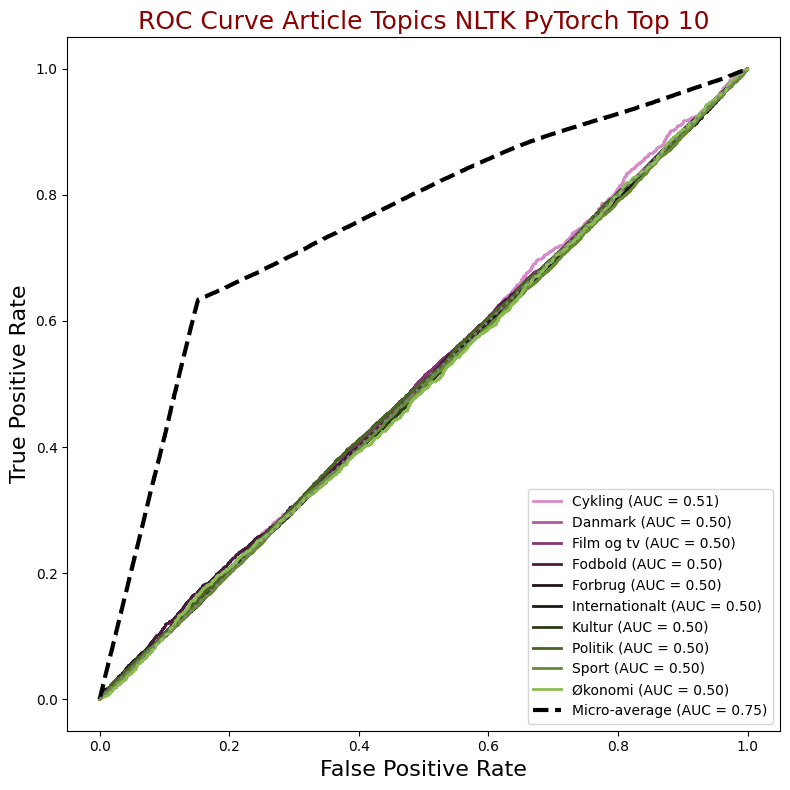

In [43]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PROBABILITIES
# --------------------------------------------------------

model.eval()

all_probabilities = []
all_truths = []

print("Generating prediction probabilities...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        probabilities = pt.softmax(outputs, dim=1)

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

all_probabilities = np.array(all_probabilities)
all_truths = np.array(all_truths)

# --------------------------------------------------------
# BINARIZE LABELS FOR MULTICLASS ROC
# --------------------------------------------------------

classes = label_encoder.classes_
num_classes = len(classes)

truths_binarized = label_binarize(
    all_truths,
    classes=np.arange(num_classes)
)

# --------------------------------------------------------
# COMPUTE ROC CURVES
# --------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        truths_binarized[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# --------------------------------------------------------
# MICRO-AVERAGE ROC
# --------------------------------------------------------

fpr["micro"], tpr["micro"], _ = roc_curve(
    truths_binarized.ravel(),
    all_probabilities.ravel()
)

roc_auc["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

# --------------------------------------------------------
# VANIMO COLOR MAP
# --------------------------------------------------------

cmap = plt.get_cmap("vanimo")

colors = cmap(
    np.linspace(0.1, 0.9, num_classes)
)

# --------------------------------------------------------
# PLOT ROC CURVES
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for i, color in zip(range(num_classes), colors):

    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Micro-average ROC
ax.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    linewidth=3,
    label=f"Micro-average (AUC = {roc_auc['micro']:.2f})"
)

# Random classifier line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray"
)

plt.title(
    "ROC Curve Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=16
)

plt.ylabel(
    "True Positive Rate",
    fontsize=16
)

plt.legend(
    fontsize=10,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ROC_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()